# Problem 1: Softmax MNIST Classification

In this problem, I implement a softmax regression classifier for the
MNIST handwritten-digit dataset. Each 28 × 28 image is flattened into
a 784-dimensional vector and passed directly to ten output units.
There are no hidden layers or learned feature-extraction layers

In [38]:
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [39]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [40]:
import torchvision
from torch.utils.data import DataLoader

transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.1307,), (0.3081,))
])

mnist_train = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

mnist_test = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

In [41]:
batch_size = 64

train_loader = DataLoader(
    mnist_train,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    mnist_test,
    batch_size=batch_size,
    shuffle=False
)

In [42]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Minimum pixel value:", images.min().item())
print("Maximum pixel value:", images.max().item())

Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])
Minimum pixel value: -0.4242129623889923
Maximum pixel value: 2.821486711502075


In [43]:
class SoftmaxRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(28 * 28, 10)

        # Simple random initialization—not Xavier or Kaiming.
        nn.init.normal_(self.linear.weight, mean=0.0, std=0.01)
        nn.init.zeros_(self.linear.bias)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        logits = self.linear(x)
        return logits

In [44]:
model = SoftmaxRegression().to(device)
print(model)

SoftmaxRegression(
  (linear): Linear(in_features=784, out_features=10, bias=True)
)


In [45]:
images, labels = next(iter(train_loader))

print("Images before model:", images.shape)
print("Labels:", labels.shape)

Images before model: torch.Size([64, 1, 28, 28])
Labels: torch.Size([64])


In [46]:
images = images.to(device)
labels = labels.to(device)

In [47]:
logits = model(images)

print("Logits shape:", logits.shape)
print("First image logits:", logits[0])
print("First image label:", labels[0])

Logits shape: torch.Size([64, 10])
First image logits: tensor([ 0.0607, -0.2321,  0.4714, -0.0765,  0.4843, -0.0724, -0.0530, -0.1280,
        -0.0980,  0.0783], device='cuda:0', grad_fn=<SelectBackward0>)
First image label: tensor(3, device='cuda:0')


In [48]:
predictions = logits.argmax(dim=1)

print("First 10 predictions:", predictions[:10])
print("First 10 labels:", labels[:10])

First 10 predictions: tensor([4, 1, 9, 2, 3, 3, 4, 4, 9, 4], device='cuda:0')
First 10 labels: tensor([3, 1, 9, 3, 8, 7, 6, 1, 1, 2], device='cuda:0')


In [49]:
criterion = nn.CrossEntropyLoss()

In [50]:
loss = criterion(logits, labels)
print("Initial batch loss:", loss.item())

Initial batch loss: 2.365299701690674


In [51]:
learning_rate = 0.001

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=learning_rate
)

In [52]:
num_epochs = 200

train_losses = []
test_accuracies = []

# We will save the weights at these epochs for visualization.
saved_weights = {}

for epoch in range(1, num_epochs + 1):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    running_loss = 0.0
    total_training_examples = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Remove gradients left over from the previous batch.
        optimizer.zero_grad()

        # Forward pass
        logits = model(images)

        # Calculate the loss
        loss = criterion(logits, labels)

        # Calculate gradients
        loss.backward()

        # Update the weights and biases
        optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        total_training_examples += batch_size

    epoch_loss = running_loss / total_training_examples
    train_losses.append(epoch_loss)

    # -------------------------
    # Test evaluation
    # -------------------------
    model.eval()

    correct = 0
    total_test_examples = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            predictions = logits.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total_test_examples += labels.size(0)

    test_accuracy = 100 * correct / total_test_examples
    test_accuracies.append(test_accuracy)

    # Save copies of the learned weights at epochs 20 and 200.
    if epoch in [20, 200]:
        saved_weights[epoch] = (
            model.linear.weight.detach().cpu().clone()
        )

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch [{epoch:3d}/{num_epochs}] "
            f"Loss: {epoch_loss:.4f} "
            f"Test Accuracy: {test_accuracy:.2f}%"
        )

Epoch [  1/200] Loss: 0.9529 Test Accuracy: 86.97%
Epoch [ 10/200] Loss: 0.3482 Test Accuracy: 90.89%
Epoch [ 20/200] Loss: 0.3149 Test Accuracy: 91.42%
Epoch [ 30/200] Loss: 0.3004 Test Accuracy: 91.73%
Epoch [ 40/200] Loss: 0.2916 Test Accuracy: 91.85%
Epoch [ 50/200] Loss: 0.2856 Test Accuracy: 91.99%
Epoch [ 60/200] Loss: 0.2811 Test Accuracy: 92.00%
Epoch [ 70/200] Loss: 0.2775 Test Accuracy: 92.09%
Epoch [ 80/200] Loss: 0.2745 Test Accuracy: 92.19%
Epoch [ 90/200] Loss: 0.2720 Test Accuracy: 92.15%
Epoch [100/200] Loss: 0.2698 Test Accuracy: 92.22%
Epoch [110/200] Loss: 0.2679 Test Accuracy: 92.21%
Epoch [120/200] Loss: 0.2662 Test Accuracy: 92.23%
Epoch [130/200] Loss: 0.2647 Test Accuracy: 92.25%
Epoch [140/200] Loss: 0.2634 Test Accuracy: 92.27%
Epoch [150/200] Loss: 0.2621 Test Accuracy: 92.41%
Epoch [160/200] Loss: 0.2609 Test Accuracy: 92.33%
Epoch [170/200] Loss: 0.2599 Test Accuracy: 92.44%
Epoch [180/200] Loss: 0.2589 Test Accuracy: 92.37%
Epoch [190/200] Loss: 0.2579 Te

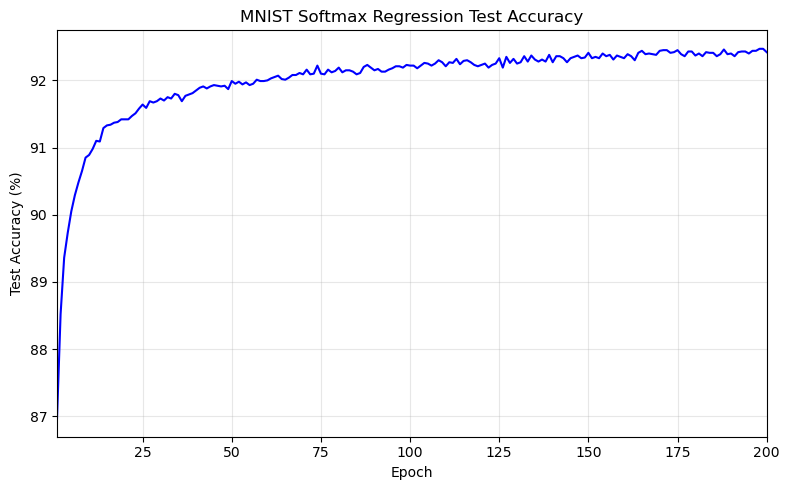

In [53]:
epochs = range(1, len(test_accuracies) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, test_accuracies, color="blue", linewidth=1.5)

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy (%)")
plt.title("MNIST Softmax Regression Test Accuracy")
plt.grid(True, alpha=0.3)
plt.xlim(1, len(test_accuracies))

plt.tight_layout()
plt.show()

In [54]:
def plot_weights(weights, epoch):
    # weights initially have shape [10, 784].
    # Reshape each class's 784 weights into a 28 × 28 image.
    weight_images = weights.reshape(10, 28, 28)

    # Use the same symmetric color scale for all ten classes.
    max_abs_weight = weight_images.abs().max().item()

    fig, axes = plt.subplots(2, 5, figsize=(12, 5))

    for digit, ax in enumerate(axes.flat):
        image = ax.imshow(
            weight_images[digit],
            cmap="seismic",
            vmin=-max_abs_weight,
            vmax=max_abs_weight
        )

        ax.set_title(f"Digit {digit}")
        ax.axis("off")

    fig.suptitle(
        f"Softmax Regression Weights at Epoch {epoch}",
        fontsize=14
    )

    fig.colorbar(
        image,
        ax=axes.ravel().tolist(),
        shrink=0.8,
        label="Weight Value"
    )

    plt.show()

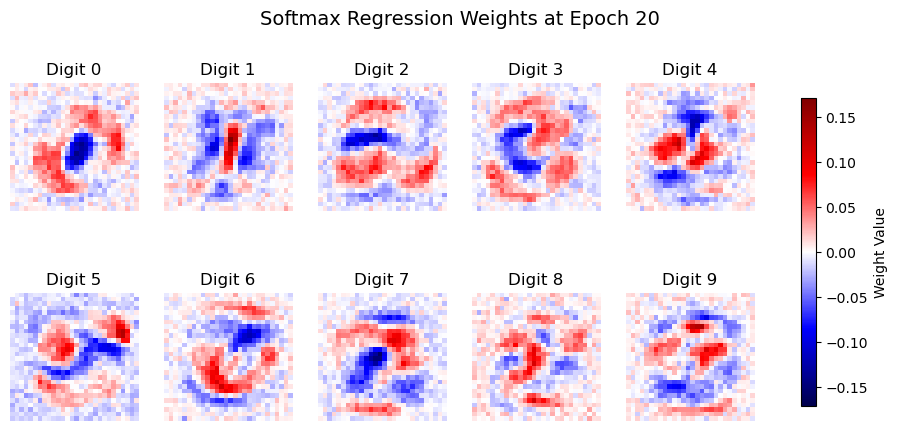

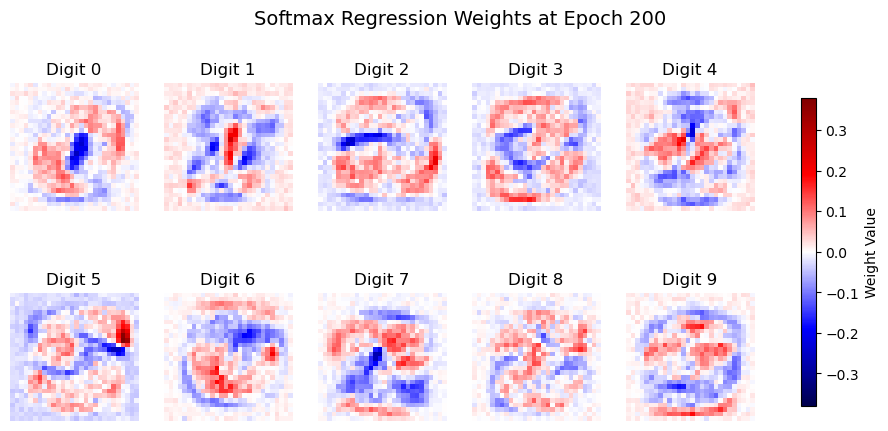

In [55]:
plot_weights(saved_weights[20], 20)
plot_weights(saved_weights[200], 200)